In [ ]:
import pandas as pd
import folium
from datetime import datetime,timedelta
import numpy as np

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/Karansingh005/San-Francisco-Crime-Data-Visualiztion/refs/heads/master/Police_Department_Incidents_-_Previous_Year__2016_.csv',na_values=['NaN','',np.nan])
df.head()

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location,PdId
0,120058272,WEAPON LAWS,POSS OF PROHIBITED WEAPON,Friday,01/29/2016 12:00:00 AM,11:00,SOUTHERN,"ARREST, BOOKED",800 Block of BRYANT ST,-122.403405,37.775421,"(37.775420706711, -122.403404791479)",1.200583e+13
1,120058272,WEAPON LAWS,"FIREARM, LOADED, IN VEHICLE, POSSESSION OR USE",Friday,01/29/2016 12:00:00 AM,11:00,SOUTHERN,"ARREST, BOOKED",800 Block of BRYANT ST,-122.403405,37.775421,"(37.775420706711, -122.403404791479)",1.200583e+13
2,141059263,WARRANTS,WARRANT ARREST,Monday,04/25/2016 12:00:00 AM,14:59,BAYVIEW,"ARREST, BOOKED",KEITH ST / SHAFTER AV,-122.388856,37.729981,"(37.7299809672996, -122.388856204292)",1.410593e+13
3,160013662,NON-CRIMINAL,LOST PROPERTY,Tuesday,01/05/2016 12:00:00 AM,23:50,TENDERLOIN,NONE,JONES ST / OFARRELL ST,-122.412971,37.785788,"(37.7857883766888, -122.412970537591)",1.600137e+13
4,160002740,NON-CRIMINAL,LOST PROPERTY,Friday,01/01/2016 12:00:00 AM,00:30,MISSION,NONE,16TH ST / MISSION ST,-122.419672,37.765050,"(37.7650501214668, -122.419671780296)",1.600027e+13


In [ ]:
#df.info()
df = df[df['Y'].isnull()==False]
df['Date'] = pd.to_datetime(df['Date'],format=("%m/%d/%Y %I:%M:%S %p"))

In [ ]:
latest_date = df['Date'].max()
seven_days_ago = latest_date - timedelta(days=7)
df_7days = df[(df['Date'] >= seven_days_ago)][['Category','X','Y']]
map = folium.Map(location=[df_7days.Y.mean(),df_7days.X.mean()],zoom_start=13)
for lat,lon,cat in zip(df_7days.Y,df_7days.X,df_7days.Category):
    folium.Marker([lat,lon],popup=cat,icon=folium.Icon(color='purple',prefix='fa',icon='people-robbery')).add_to(map)
map

#OUTPUT :
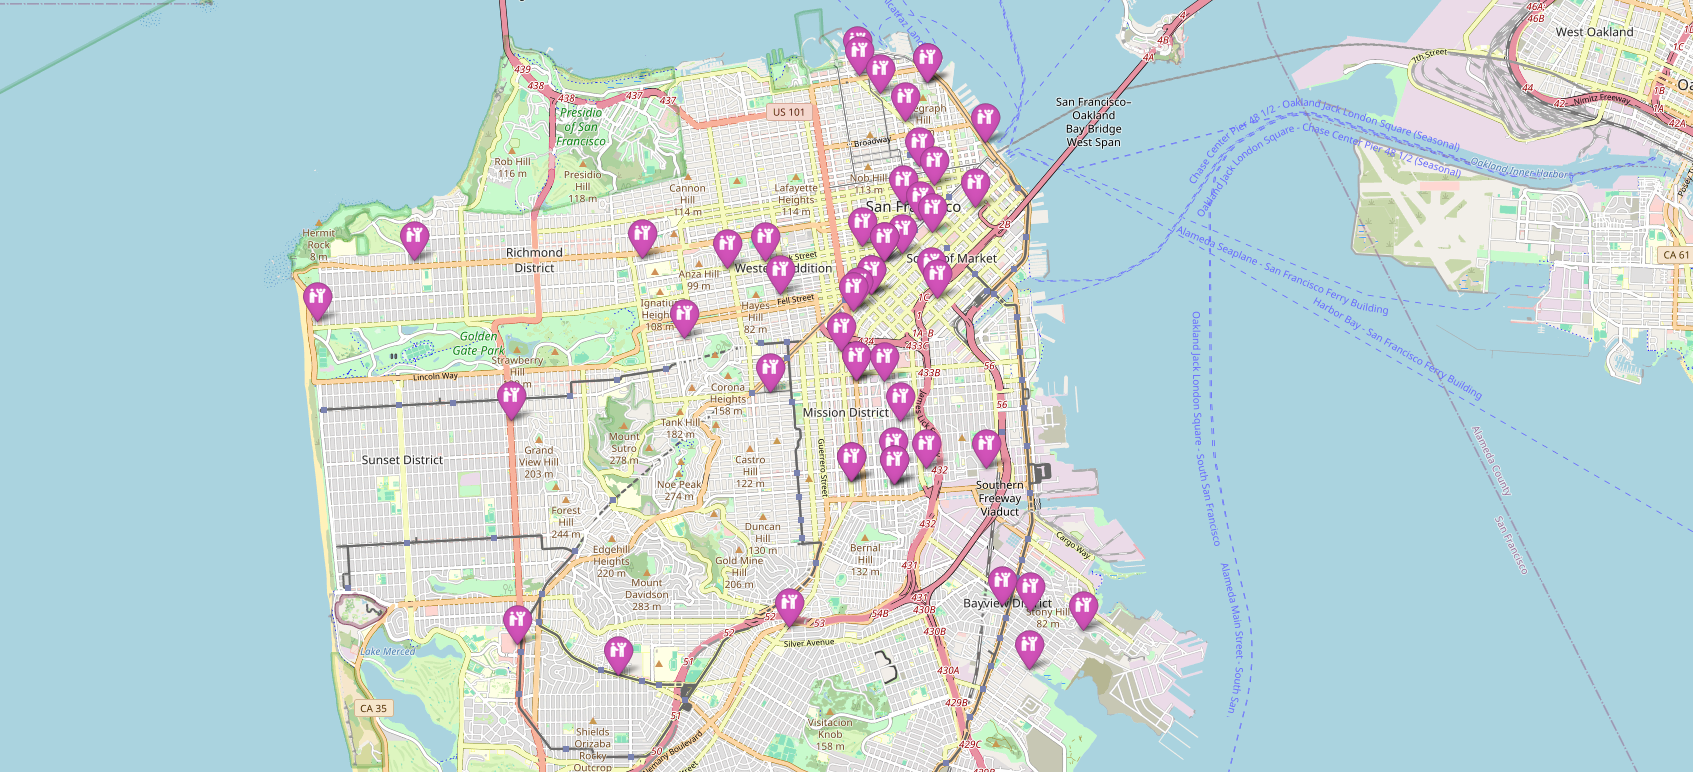

In [ ]:
fifteenth_days_ago = latest_date - timedelta(days=15)
df_15days = df[(df['Date'] >= fifteenth_days_ago)]
map = folium.Map(location=[df_15days.Y.mean(),df_15days.X.mean()],zoom_start=13)
for lat,lon,cat in zip(df_15days.Y,df_15days.X,df_15days.Category):
    folium.Marker([lat,lon],popup=cat,icon=folium.Icon(color='red',prefix='fa',icon='handcuffs')).add_to(map)
map

#OUTPUT
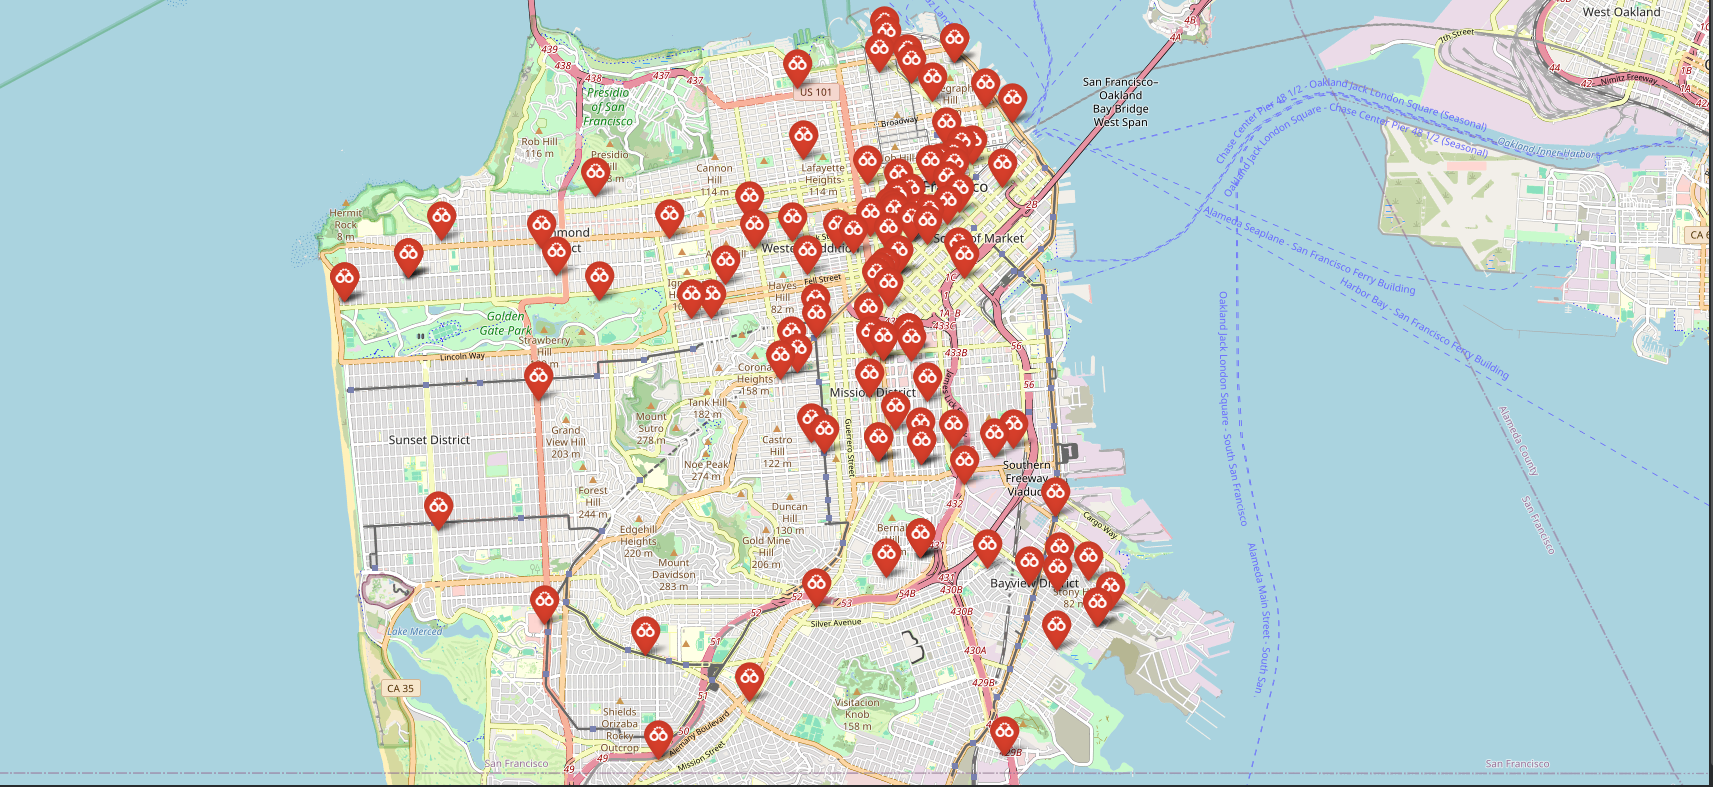